# 1D Pegasus Thermodynamic Plots

This notebook reproduces the 2D plotting workflow for the 1D Pegasus chain data.

It loads the aggregated 1D results from:
`data/results/phase_diagrams_1d_pegasus_unif_small_h`

The resulting figures show thermodynamic quantities and beta2 trends as functions of annealing parameter for selected beta1 values.

## 1. Set Up Notebook Environment

In [14]:
import os
from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy import optimize

np.set_printoptions(precision=4, suppress=True)
plt.style.use("default")

# Physical constants used by the 1D optimization pipeline
B0 = 1.0
h = 6.62607015e-34
kb = 1.380649e-23
energy_units = (B0 / 2.0) * 10**9 * h
beta_units = kb / energy_units

ROOT = os.getcwd()
if os.path.basename(ROOT) != "plots" and os.path.exists(os.path.join(ROOT, "plots", "plots_1d.ipynb")):
    ROOT = os.path.join(ROOT, "plots")


def latex_plot(scale: float = 1.0, fontsize: int = 12) -> None:
    """Set publication-style matplotlib defaults."""
    fig_width_pt = 246.0
    inches_per_pt = 1.0 / 72.27
    golden_mean = (np.sqrt(5.0) - 1.0) / 2.0
    fig_width = fig_width_pt * inches_per_pt * scale
    fig_height = fig_width * golden_mean
    mpl.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": True,
            "font.family": "serif",
            "axes.labelsize": fontsize,
            "font.size": fontsize,
            "legend.fontsize": fontsize,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "figure.figsize": [fig_width, fig_height],
        }
    )


print("Notebook environment ready.")

Notebook environment ready.


## 2. Load and Aggregate 1D Results

In [15]:
hname = "unif_small_h"
chain_lengths = [300]

DATA_PATH = f"{ROOT}/../data/results/phase_diagrams_1d_pegasus_{hname}"
print(f"Loading 1D results from {DATA_PATH}")

beta_data_raw = np.load(f"{DATA_PATH}/betas2_300.pkl", allow_pickle=True)
Q_data_raw = np.load(f"{DATA_PATH}/Q_300.pkl", allow_pickle=True)
energies_raw = np.load(f"{DATA_PATH}/energies_300.pkl", allow_pickle=True)

if hasattr(beta_data_raw, "item") and not isinstance(beta_data_raw, dict):
    beta_data_raw = beta_data_raw.item()
if hasattr(Q_data_raw, "item") and not isinstance(Q_data_raw, dict):
    Q_data_raw = Q_data_raw.item()
if hasattr(energies_raw, "item") and not isinstance(energies_raw, dict):
    energies_raw = energies_raw.item()

print(f"Loaded beta entries: {len(beta_data_raw)}")
print(f"Loaded Q entries: {len(Q_data_raw)}")
print(f"Loaded energies entries: {len(energies_raw)}")

# Collect the available parameter grids
available_annealing_params = sorted({float(k[2]) for k in beta_data_raw.keys() if int(k[0]) == 300})
available_annealing_times = sorted({float(k[1]) for k in beta_data_raw.keys() if int(k[0]) == 300})
available_beta1s = sorted({float(k[3]) for k in beta_data_raw.keys() if int(k[0]) == 300})

print(f"Detected annealing parameters: {available_annealing_params}")
print(f"Detected annealing times: {available_annealing_times}")
print(f"Detected beta1 values: {available_beta1s}")
print("Available parameter coverage by annealing time:")
for at in available_annealing_times:
    at_keys = [k for k in beta_data_raw.keys() if int(k[0]) == 300 and np.isclose(float(k[1]), at)]
    params_for_time = sorted({float(k[2]) for k in at_keys})
    beta1s_for_time = sorted({float(k[3]) for k in at_keys})
    print(
        f"  at={at:g} us: annealing_params={params_for_time}; "
        f"beta1_count={len(beta1s_for_time)}, beta1_range="
        f"[{min(beta1s_for_time):.3f}, {max(beta1s_for_time):.3f}]"
    )

# Build result arrays matching the 2D notebook layout: [name, beta1, ap, time]
# Here there is a single dataset name and a single chain length.
shape = (1, len(available_beta1s), len(available_annealing_params), len(available_annealing_times))
beta2 = np.full(shape, np.nan)
work = np.full(shape, np.nan)
power = np.full(shape, np.nan)
dE = np.full(shape, np.nan)
varE = np.full(shape, np.nan)
gval = np.full(shape, np.nan)
Tgval = np.full(shape, np.nan)
betas = np.full(shape, np.nan)
dE2 = np.full(shape, np.nan)

# Fill arrays directly from the 1D result dictionaries.
for bidx, beta1 in enumerate(available_beta1s):
    beta1_key = f"{beta1:.3f}"
    for j, ap in enumerate(available_annealing_params):
        ap_key = f"{ap:.3f}"
        for k, at in enumerate(available_annealing_times):
            at_key = f"{at:g}" if float(at).is_integer() else f"{at:.3f}"
            lookup_key = ("300", at_key, ap_key, beta1_key)
            if lookup_key not in beta_data_raw or lookup_key not in Q_data_raw or lookup_key not in energies_raw:
                continue

            beta2_val = -float(beta_data_raw[lookup_key])
            Qmean, Qvar = Q_data_raw[lookup_key]
            Emean, Evar = energies_raw[lookup_key]
            # print(f"Processing beta1={beta1:.3f}, ap={ap:.3f}, at={at_key}: beta2={beta2_val:.4f}, Qmean={Qmean:.4f}, Qvar={Qvar:.4f}")

            if np.isnan(beta2_val) or abs(beta2_val) <= 1e-10:
                continue
            if abs(Qmean) <= 1e-10 and abs(Qvar) <= 1e-10:
                continue

            x = Qmean / np.sqrt(Qvar + Qmean**2)
            gx = x * np.arctanh(x)

            beta2[0, bidx, j, k] = beta2_val
            work[0, bidx, j, k] = 2 / beta2_val * gx + (1 - (beta1 / beta2_val)) * Qmean
            power[0, bidx, j, k] = work[0, bidx, j, k] / (at * 10 ** (-6))
            dE[0, bidx, j, k] = Qmean
            varE[0, bidx, j, k] = Qvar
            gval[0, bidx, j, k] = gx
            Tgval[0, bidx, j, k] = 2 * gx / beta2_val
            betas[0, bidx, j, k] = 1 - beta1 / beta2_val
            dE2[0, bidx, j, k] = 2 * gx / beta2_val - (beta1 / beta2_val) * Qmean

results = {
    300: {
        "beta2": beta2,
        "work": work,
        "power": power,
        "dE": dE,
        "dE2": dE2,
        "varE": varE,
        "gval": gval,
        "Tgval": Tgval,
        "betas": betas,
        "num_var": 300,
        "annealing_params": available_annealing_params,
        "annealing_times": available_annealing_times,
        "beta1s": available_beta1s,
    }
}

print("1D results aggregated into plotting arrays.")

Loading 1D results from /home/jpawlowski/velox/pegasus-thermodynamic/plots/../data/results/phase_diagrams_1d_pegasus_unif_small_h
Loaded beta entries: 2685
Loaded Q entries: 2685
Loaded energies entries: 2685
Detected annealing parameters: [0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.62, 0.66, 0.7, 0.8, 0.9]
Detected annealing times: [10.0, 100.0, 1000.0, 2000.0]
Detected beta1 values: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7, 2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.05, 3.1, 3.15, 3.2, 

## 3. Thermodynamic Quantities and Beta2 vs Annealing Parameter

Number of variables: 300
Plotting with 56 annealing params, 4 times, 110 beta1s
Selected beta1 values for plotting: [0.75, 1.05, 1.55, 2.05, 2.55, 3.05, 3.55, 4.05, 4.55]
Selected annealing time: 100 μs (target: 100 μs)


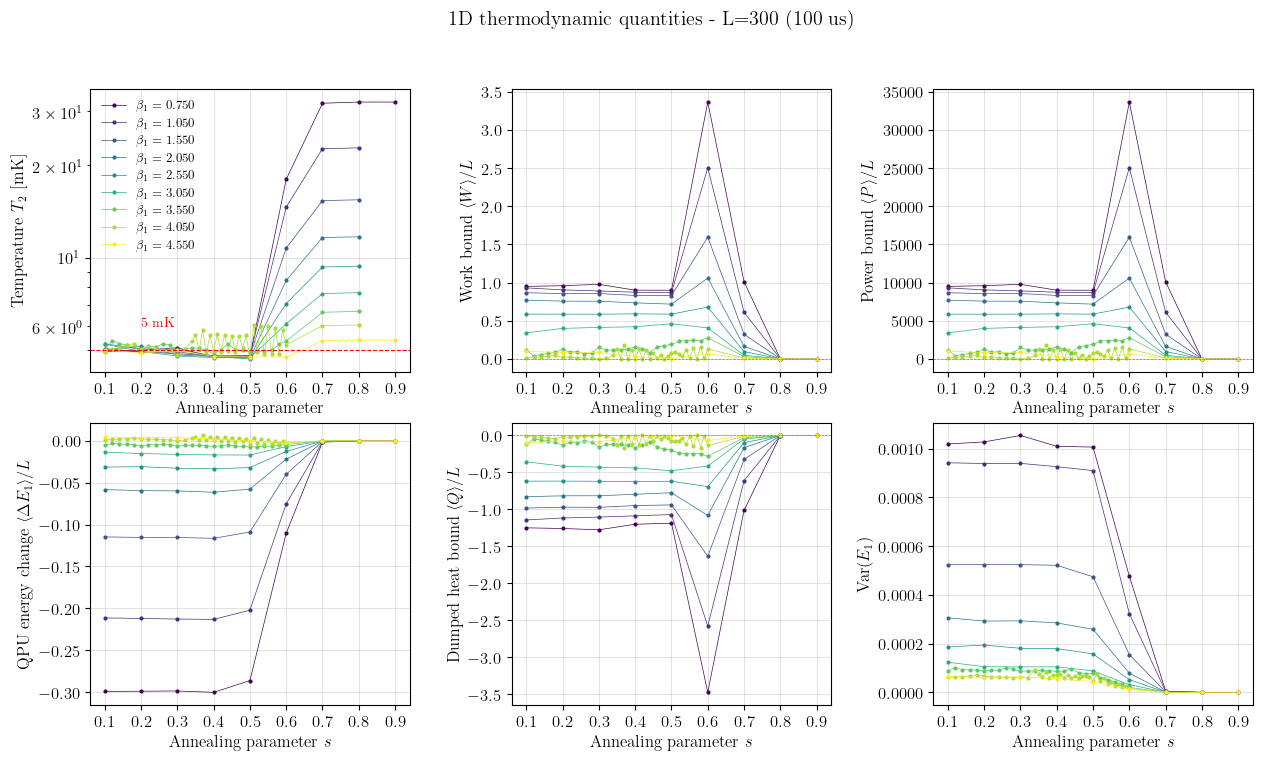

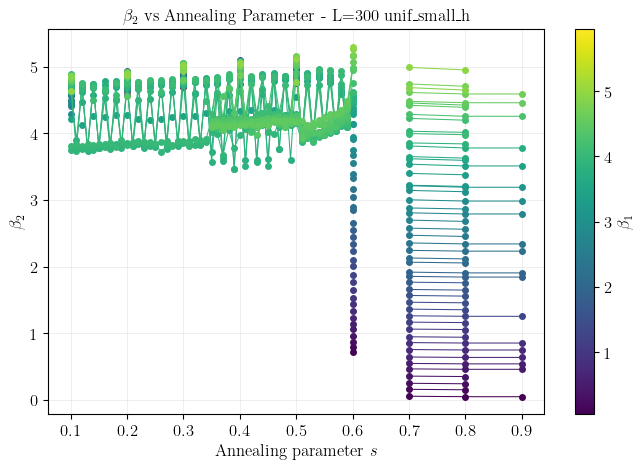

In [35]:
# Create plots from the 1D `results` dictionary
font_size = 12
line_style = "-"
line_width = 0.5
marker_size = 2
markers_list = ["o", "s", "^", "v", "D", "*"]

for chain_length in chain_lengths:
    arr = results[chain_length]
    num_var = arr["num_var"]
    annealing_params = np.array(arr["annealing_params"])
    annealing_times = arr["annealing_times"]
    beta1s = arr["beta1s"]

    print(f"Number of variables: {num_var}")
    print(f"Plotting with {len(annealing_params)} annealing params, {len(annealing_times)} times, {len(beta1s)} beta1s")


    plot_beta1s = [0.75, 1.05, 1.55, 2.05, 2.55, 3.05, 3.55, 4.05, 4.55]
    # plot_beta1s = [4.40, 4.45, 4.50]
    print("Selected beta1 values for plotting:", plot_beta1s)
    plot_cmap = plt.get_cmap("viridis", len(plot_beta1s))
    plot_beta1_colors = {beta1: plot_cmap(i) for i, beta1 in enumerate(plot_beta1s)}

    # Fix annealing time to 10 us (fallback to nearest available time).
    selected_time_us = 100.0
    if selected_time_us in annealing_times:
        selected_time_idx = annealing_times.index(selected_time_us)
    else:
        selected_time_idx = int(np.argmin(np.abs(np.array(annealing_times) - selected_time_us)))
    selected_time = annealing_times[selected_time_idx]
    print(f"Selected annealing time: {selected_time:g} μs (target: {selected_time_us:g} μs)")

    # latex_plot(scale=1, fontsize=font_size)
    from matplotlib import gridspec
    fig = plt.figure(figsize=(15, 8))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.18, wspace=0.32)
    axs = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]

    beta2 = arr["beta2"]
    work = arr["work"]
    power = arr["power"]
    dE = arr["dE"]
    varE = arr["varE"]
    dE2 = arr["dE2"]

    # Panel 1: T2
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        label = fr"$\beta_1={beta1:.3f}$"
        color = plot_beta1_colors[beta1]
        beta2val = arr["beta2"][0, bidx, :, selected_time_idx]
        nonnan_mask = ~np.isnan(beta2val)
        T2val = 1 / (beta_units*beta2val) * 1000
        p = axs[0].plot(
            np.array(annealing_params)[nonnan_mask],
            T2val[nonnan_mask],
            # beta2[0, bidx, :, selected_time_idx],
            color=color,
            label=label,
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
        T1 = 1 / (beta_units*beta1) * 1000
        # axs[0].axhline(T1, color=p[0].get_color(), linestyle="--", linewidth=0.8, alpha=0.7)
    axs[0].axhline(5, color="red", linestyle="--", linewidth=0.8)
    axs[0].text(0.2, 6, "5 mK", color="red", fontsize=10)
    axs[0].set_xlabel("Annealing parameter")
    axs[0].set_ylabel(r"Temperature $T_2$ [mK]", fontsize=font_size)
    # axs[0].set_ylabel(r"Inv. temperature $\beta_2$", fontsize=font_size)
    axs[0].set_yscale("log")
    axs[0].legend(loc="best", frameon=False, markerscale=1, fontsize=9)

    # Panel 2: Work
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        color = plot_beta1_colors[beta1]
        nonnan_mask = ~np.isnan(work[0, bidx, :, selected_time_idx])
        p = axs[1].plot(
            annealing_params[nonnan_mask],
            work[0, bidx, nonnan_mask, selected_time_idx],
            color=color,
            label=fr"$\beta_1={beta1:.3f}$",
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
    axs[1].set_xlabel(r"Annealing parameter $s$")
    axs[1].set_ylabel(r"Work bound $\langle W \rangle/L$", fontsize=font_size)
    axs[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)

    # Panel 3: Power
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        color = plot_beta1_colors[beta1]
        nonnan_mask = ~np.isnan(power[0, bidx, :, selected_time_idx])
        axs[2].plot(
            annealing_params[nonnan_mask],
            power[0, bidx, nonnan_mask, selected_time_idx],
            color=color,
            label=fr"$\beta_1={beta1:.3f}$",
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
    axs[2].set_xlabel(r"Annealing parameter $s$")
    axs[2].set_ylabel(r"Power bound $\langle P \rangle/L$", fontsize=font_size)
    axs[2].axhline(0, color="gray", linestyle="--", linewidth=0.5)

    # Panel 4: dE1
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        color = plot_beta1_colors[beta1]
        nonnan_mask = ~np.isnan(dE[0, bidx, :, selected_time_idx])
        axs[3].plot(
            annealing_params[nonnan_mask],
            dE[0, bidx, nonnan_mask, selected_time_idx],
            color=color,
            label=fr"$\beta_1={beta1:.3f}$",
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
    axs[3].set_xlabel(r"Annealing parameter $s$")
    axs[3].set_ylabel(r"QPU energy change $\langle \Delta E_1 \rangle/L$", fontsize=font_size)

    # Panel 5: dE2
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        color = plot_beta1_colors[beta1]
        nonnan_mask = ~np.isnan(dE2[0, bidx, :, selected_time_idx])
        axs[4].plot(
            annealing_params[nonnan_mask],
            -dE2[0, bidx, nonnan_mask, selected_time_idx],
            color=color,
            label=fr"$\beta_1={beta1:.3f}$",
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
    axs[4].set_xlabel(r"Annealing parameter $s$")
    axs[4].set_ylabel(r"Dumped heat bound $\langle Q \rangle/L$", fontsize=font_size)
    axs[4].axhline(0, color="gray", linestyle="--", linewidth=0.5)

    # Panel 6: Var(E1)
    for bidx, beta1 in enumerate(beta1s):
        if beta1 not in plot_beta1s:
            continue
        color = plot_beta1_colors[beta1]
        nonnan_mask = ~np.isnan(varE[0, bidx, :, selected_time_idx])
        axs[5].plot(
            annealing_params[nonnan_mask],
            varE[0, bidx, nonnan_mask, selected_time_idx],
            color=color,
            label=fr"$\beta_1={beta1:.3f}$",
            marker='o',
            markersize=marker_size,
            linestyle=line_style,
            linewidth=line_width,
        )
    axs[5].set_xlabel(r"Annealing parameter $s$")
    axs[5].set_ylabel(r"Var($E_1$)", fontsize=font_size)

    for ax in axs:
        ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

    plt.suptitle(f"1D thermodynamic quantities - L={chain_length} ({selected_time:g} us)")
    # plt.tight_layout()
    # plt.savefig(f"thermodynamics_quantities_1d_L{chain_length}_{hname}.pdf", bbox_inches='tight')
    plt.show()

    # Beta2 vs annealing parameter
    latex_plot(scale=1, fontsize=12)
    fig, ax = plt.subplots(figsize=(8, 5))

    norm = Normalize(vmin=min(beta1s), vmax=max(beta1s))
    cmap = plt.get_cmap('viridis')

    for bidx, beta1 in enumerate(beta1s):
        # if beta1 not in plot_beta1s:
            # continue
        color = cmap(norm(beta1))
        beta2_plot = beta2[0, bidx, :, selected_time_idx]
        ax.plot(
            annealing_params,
            beta2_plot,
            color=color,
            marker='o',
            markersize=4,
            linestyle='-',
            linewidth=0.75,
            label=fr'$\beta_1={beta1:.3f}$',
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r'$\beta_1$', fontsize=12)

    ax.set_xlabel(r'Annealing parameter $s$', fontsize=12)
    ax.set_ylabel(r'$\beta_2$', fontsize=12)
    ax.set_title(fr'$\beta_2$ vs Annealing Parameter - L={chain_length} {hname}', fontsize=12)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3)
    # plt.tight_layout()
    plt.savefig(f"1d_chain/beta2_vs_annealing_at_{selected_time_us}_1d_L{chain_length}_{hname}.pdf", bbox_inches='tight')
    plt.show()

## 4. Scaling vs L at fixed beta1

This section loads the 1D scaling dataset from `scaling_1d_pegasus_unif_small_h` and plots
thermodynamic quantities versus chain length `L` at fixed `\beta_1 = 1.0` and `\beta_1 = 4.5`.

For each quantity, the figure has two panels (one per `\beta_1`) and includes a separate curve
for each annealing parameter `s`.


Loading scaling data from /home/jpawlowski/velox/pegasus-thermodynamic/plots/../data/results/scaling_1d_pegasus_unif_small_h
Chain lengths: [50, 100, 500, 1000, 2000]
Target beta1 values: [1.0, 4.5]
Selected annealing time: 100 us
L=50: betas=18, Q=18, energies=18
L=100: betas=36, Q=36, energies=36
L=500: betas=54, Q=54, energies=54
L=1000: betas=72, Q=72, energies=72
L=2000: betas=90, Q=90, energies=90
Found annealing parameters s: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Coverage for T2_mK:
  beta1=1.0: {0.1: 5, 0.2: 5, 0.3: 5, 0.4: 5, 0.5: 5, 0.6: 5, 0.7: 5, 0.8: 5, 0.9: 5}
  beta1=4.5: {0.1: 5, 0.2: 5, 0.3: 5, 0.4: 5, 0.5: 5, 0.6: 5, 0.7: 5, 0.8: 5, 0.9: 5}

Coverage for work:
  beta1=1.0: {0.1: 5, 0.2: 5, 0.3: 5, 0.4: 5, 0.5: 5, 0.6: 5, 0.7: 5, 0.8: 5, 0.9: 5}
  beta1=4.5: {0.1: 5, 0.2: 5, 0.3: 5, 0.4: 5, 0.5: 5, 0.6: 5, 0.7: 5, 0.8: 5, 0.9: 5}

Coverage for power:
  beta1=1.0: {0.1: 5, 0.2: 5, 0.3: 5, 0.4: 5, 0.5: 5, 0.6: 5, 0.7: 5, 0.8: 5, 0.9: 5}
  beta1=4.5: {0.1: 5, 0.2

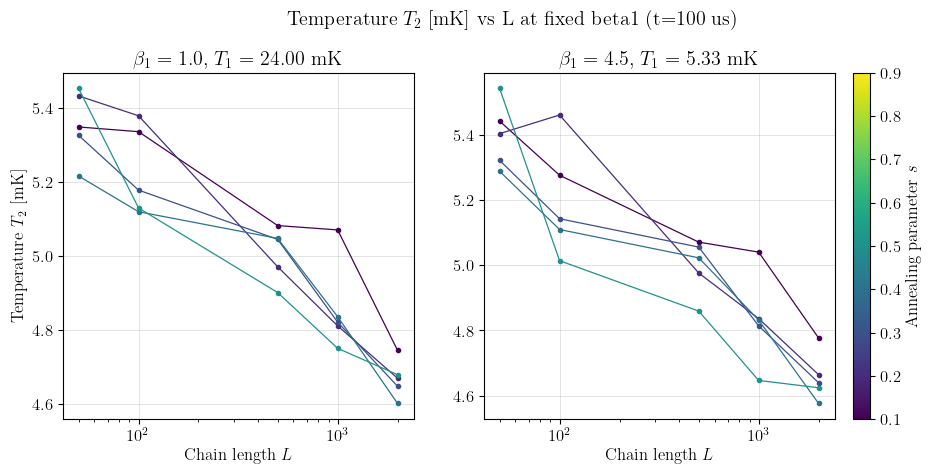

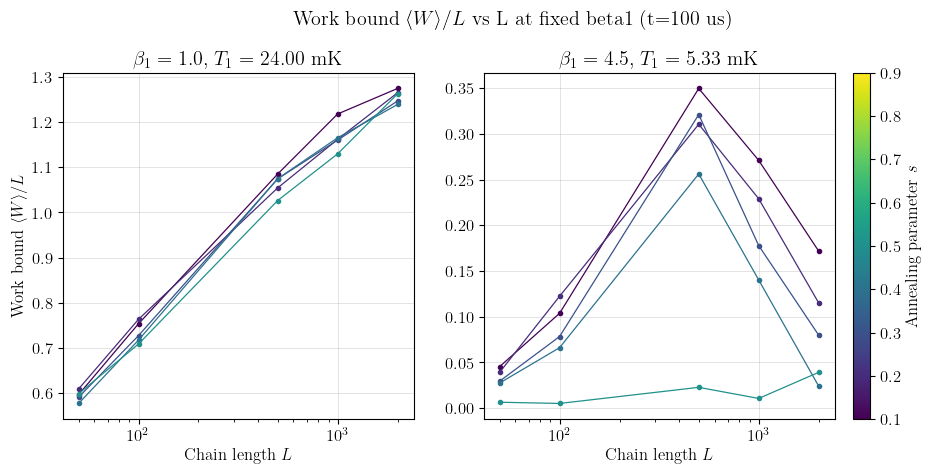

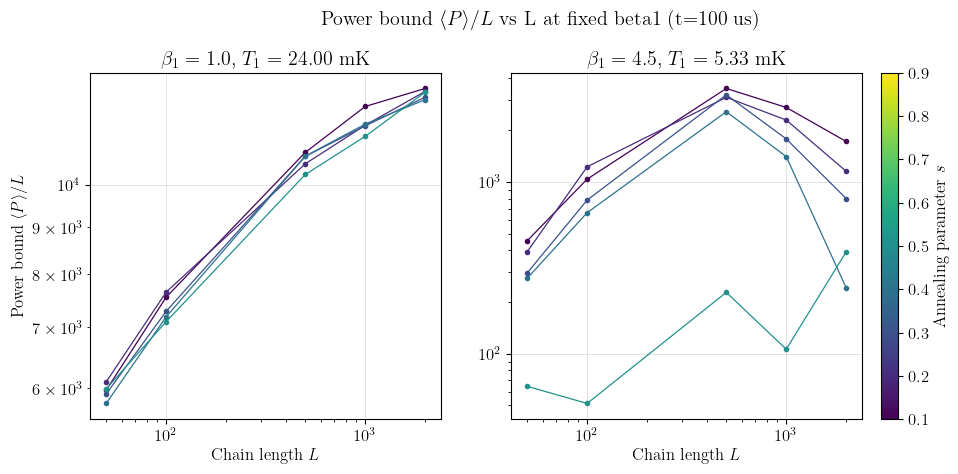

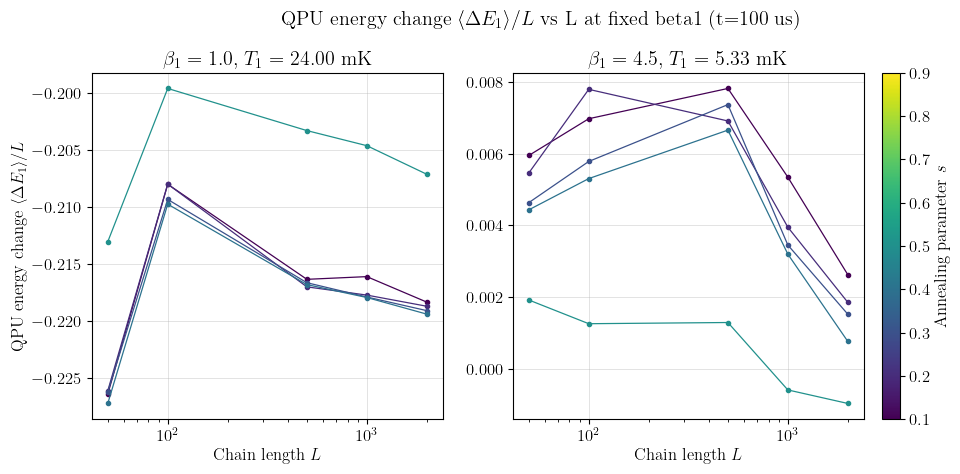

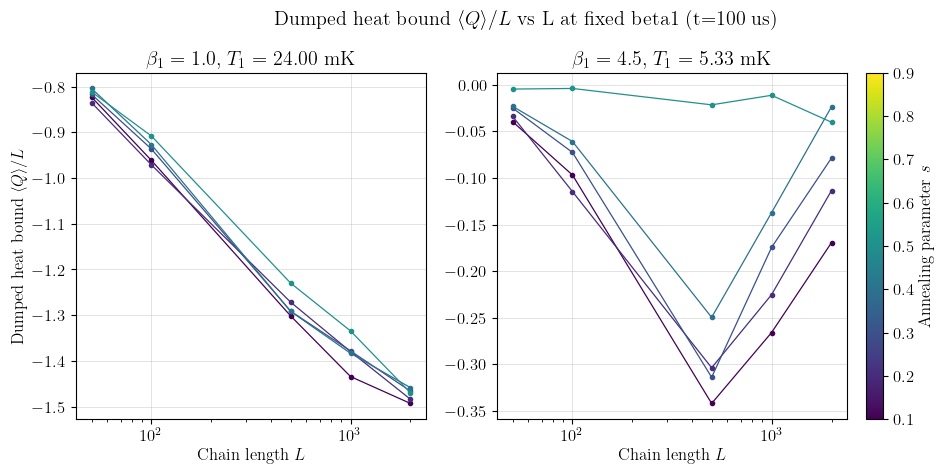

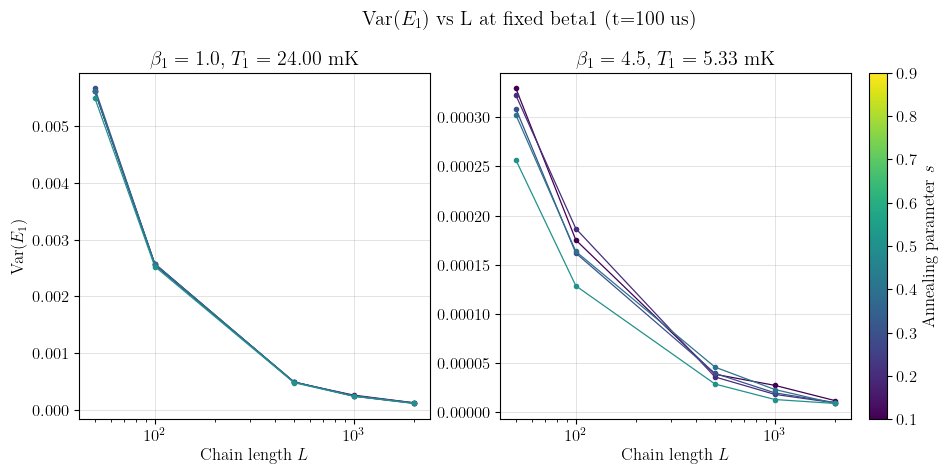

In [22]:
# Scaling analysis vs chain length L at fixed beta1
scaling_path = f"{ROOT}/../data/results/scaling_1d_pegasus_unif_small_h"
scaling_chain_lengths = [50, 100, 500, 1000, 2000]
beta1_targets = [1.0, 4.5]
selected_time_us = 100.0

print(f"Loading scaling data from {scaling_path}")
print(f"Chain lengths: {scaling_chain_lengths}")
print(f"Target beta1 values: {beta1_targets}")
print(f"Selected annealing time: {selected_time_us:g} us")


def _as_dict(obj):
    if hasattr(obj, "item") and not isinstance(obj, dict):
        return obj.item()
    return obj


records = []
found_beta1s = set()
found_s_values = set()

for L in scaling_chain_lengths:
    scaling_path_L = f"{ROOT}/../data/results/phase_diagrams_1d_pegasus_unif_small_h" if L == 300 else scaling_path
    beta_raw = _as_dict(np.load(f"{scaling_path_L}/betas2_{L}.pkl", allow_pickle=True))
    q_raw = _as_dict(np.load(f"{scaling_path_L}/Q_{L}.pkl", allow_pickle=True))
    e_raw = _as_dict(np.load(f"{scaling_path_L}/energies_{L}.pkl", allow_pickle=True))

    print(f"L={L}: betas={len(beta_raw)}, Q={len(q_raw)}, energies={len(e_raw)}")

    for key, beta_est in beta_raw.items():
        if key not in q_raw or key not in e_raw:
            continue

        L_key, at_key, s_key, b1_key = key
        if int(float(L_key)) != L:
            continue

        anneal_time = float(at_key)
        if not np.isclose(anneal_time, selected_time_us):
            continue

        s_val = float(s_key)
        beta1_val = float(b1_key)

        match_beta1 = None
        for target in beta1_targets:
            if np.isclose(beta1_val, target):
                match_beta1 = target
                break
        if match_beta1 is None:
            continue

        beta2_val = -float(beta_est)
        if np.isnan(beta2_val) or abs(beta2_val) <= 1e-10:
            continue

        Qmean, Qvar = q_raw[key]
        Emean, Evar = e_raw[key]

        x = Qmean / np.sqrt(Qvar + Qmean**2)
        gx = x * np.arctanh(x)

        work_val = 2 / beta2_val * gx + (1 - (match_beta1 / beta2_val)) * Qmean
        power_val = work_val / (selected_time_us * 10 ** (-6))
        dE_val = Qmean
        varE_val = Qvar
        dE2_val = 2 * gx / beta2_val - (match_beta1 / beta2_val) * Qmean
        dumped_heat_val = -dE2_val
        T2_mK_val = 1000.0 / (beta2_val * beta_units)

        records.append(
            {
                "L": L,
                "beta1": match_beta1,
                "s": s_val,
                "T2_mK": T2_mK_val,
                "work": work_val,
                "power": power_val,
                "dE": dE_val,
                "dumped_heat": dumped_heat_val,
                "varE": varE_val,
            }
        )
        found_beta1s.add(match_beta1)
        found_s_values.add(s_val)

if len(found_beta1s) != len(beta1_targets):
    raise ValueError(f"Missing beta1 targets. Found={sorted(found_beta1s)}, expected={beta1_targets}")

s_values = sorted(found_s_values)
# s_values = [s for s in s_values if s <= 0.6]
print(f"Found annealing parameters s: {s_values}")

quantity_specs = [
    ("T2_mK", r"Temperature $T_2$ [mK]"),
    ("work", r"Work bound $\langle W \rangle/L$"),
    ("power", r"Power bound $\langle P \rangle/L$"),
    ("dE", r"QPU energy change $\langle \Delta E_1 \rangle/L$"),
    ("dumped_heat", r"Dumped heat bound $\langle Q \rangle/L$"),
    ("varE", r"Var($E_1$)"),
]

metric_data = {
    metric: {
        beta1: {s: [] for s in s_values}
        for beta1 in beta1_targets
    }
    for metric, _ in quantity_specs
}

for row in records:
    for metric, _ in quantity_specs:
        metric_data[metric][row["beta1"]][row["s"]].append((row["L"], row[metric]))

for metric, _ in quantity_specs:
    print(f"\nCoverage for {metric}:")
    for beta1 in beta1_targets:
        counts = {s: len(metric_data[metric][beta1][s]) for s in s_values}
        print(f"  beta1={beta1}: {counts}")

cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=min(s_values), vmax=max(s_values))

for metric, ylabel in quantity_specs:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

    for ax, beta1 in zip(axs, beta1_targets):
        for s in s_values:
            if s >= 0.6:
                continue
            points = sorted(metric_data[metric][beta1][s], key=lambda x: x[0])
            if not points:
                continue
            L_vals = [p[0] for p in points]
            y_vals = [p[1] for p in points]
            ax.plot(
                L_vals,
                y_vals,
                marker="o",
                markersize=3,
                linewidth=0.9,
                color=cmap(norm(s)),
                label=fr"$s={s:.1f}$",
            )
        
        if metric == 'power':
            ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_title(fr"$\beta_1={beta1:.1f}$, $T_1={1000.0 / (beta1 * beta_units):.2f}$ mK")
        ax.set_xlabel(r"Chain length $L$")
        ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.5)

    axs[0].set_ylabel(ylabel)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), pad=0.02)
    cbar.set_label(r"Annealing parameter $s$")

    fig.suptitle(
        f"{ylabel} vs L at fixed beta1 (t={selected_time_us:g} us)",
        y=1.02,
    )
    # plt.tight_layout()
    plt.show()


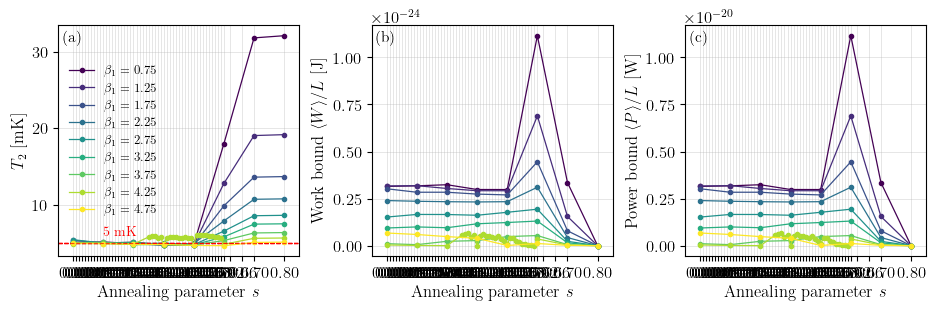

In [23]:
# Physical-unit 1D thermodynamic quantities at fixed annealing time
latex_plot(scale=1.6, fontsize=12)

physical_chain_length = 300
physical_selected_time_us = 100.0
physical_plot_beta1s = [0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75]
max_ap = 0.8

arr = results[physical_chain_length]
annealing_params = arr["annealing_params"]
annealing_times = arr["annealing_times"]
beta1s = arr["beta1s"]

if physical_selected_time_us in annealing_times:
    selected_time_idx = annealing_times.index(physical_selected_time_us)
else:
    selected_time_idx = int(np.argmin(np.abs(np.array(annealing_times) - physical_selected_time_us)))
selected_time = annealing_times[selected_time_idx]

from matplotlib import gridspec
fig = plt.figure(figsize=(11.2, 3))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)
axs = [fig.add_subplot(gs[0, j]) for j in range(3)]
plot_cmap = plt.get_cmap("viridis", len(physical_plot_beta1s))
plot_beta1_colors = {beta1: plot_cmap(i) for i, beta1 in enumerate(physical_plot_beta1s)}

for beta1 in physical_plot_beta1s:
    if beta1 not in beta1s:
        print(f"Skipping beta1={beta1:.3f}: not available in L={physical_chain_length} results")
        continue

    bidx = beta1s.index(beta1)
    color = plot_beta1_colors[beta1]
    T1_mK = 1000.0 / (beta1 * beta_units)
    label = fr"$\beta_1={beta1:.2f}$"

    beta2_vals = arr["beta2"][0, bidx, :, selected_time_idx]
    work_per_spin = arr["work"][0, bidx, :, selected_time_idx] * energy_units
    power_per_spin = work_per_spin / (selected_time * 1e-6)
    t2_mK = 1000.0 / (beta2_vals * beta_units)

    valid = np.isfinite(t2_mK) & np.isfinite(work_per_spin) & np.isfinite(power_per_spin) & (np.array(annealing_params) <= max_ap)
    if not np.any(valid):
        print(f"Skipping beta1={beta1:.3f}: no finite values at t={selected_time:g} us")
        continue

    x_vals = np.array(annealing_params)[valid]
    axs[0].plot(x_vals, t2_mK[valid], color=color, marker="o", markersize=3, linewidth=0.9, label=label)
    axs[0].axhline(5, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    axs[1].plot(x_vals, work_per_spin[valid], color=color, marker="o", markersize=3, linewidth=0.9, label=label)
    axs[2].plot(x_vals, power_per_spin[valid], color=color, marker="o", markersize=3, linewidth=0.9, label=label)

axs[0].set_ylabel(r"$T_2$ [mK]")
axs[1].set_ylabel(r"Work bound $\langle W \rangle/L$ [J]")
axs[2].set_ylabel(r"Power bound $\langle P \rangle/L$ [W]")
panel_labels = ["(a)", "(b)", "(c)"]
for panel_idx, ax in enumerate(axs):
    ax.text(0.02, 0.98, panel_labels[panel_idx], transform=ax.transAxes, ha="left", va="top", fontsize=11)

axs[0].set_xlim(0.05, 0.85)
axs[1].set_xlim(0.05, 0.85)
axs[2].set_xlim(0.05, 0.85)

axs[0].text(0.2, 6, "5 mK", color="red", fontsize=10)

power_lines = [line.get_ydata() for line in axs[2].lines]
# if power_lines:
    # power_values = np.concatenate([np.asarray(vals, dtype=float) for vals in power_lines])
    # if np.all(power_values[np.isfinite(power_values)] > 0):
        # axs[2].set_yscale("log")

for ax in axs:
    ax.set_xlabel(r"Annealing parameter $s$")
    ax.set_xticks(annealing_params[:-1])
    ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.45)

axs[0].legend(loc="best", frameon=False, fontsize=9)
# fig.suptitle(fr"Physical per-spin bounds, $L={physical_chain_length}$, $t={selected_time:g}\,\mu s$", y=1.02)
plt.savefig(f"1d_chain/bounds_vs_annealing_at_{selected_time_us}_1d_L{physical_chain_length}_{hname}.pdf", bbox_inches='tight')
plt.show()


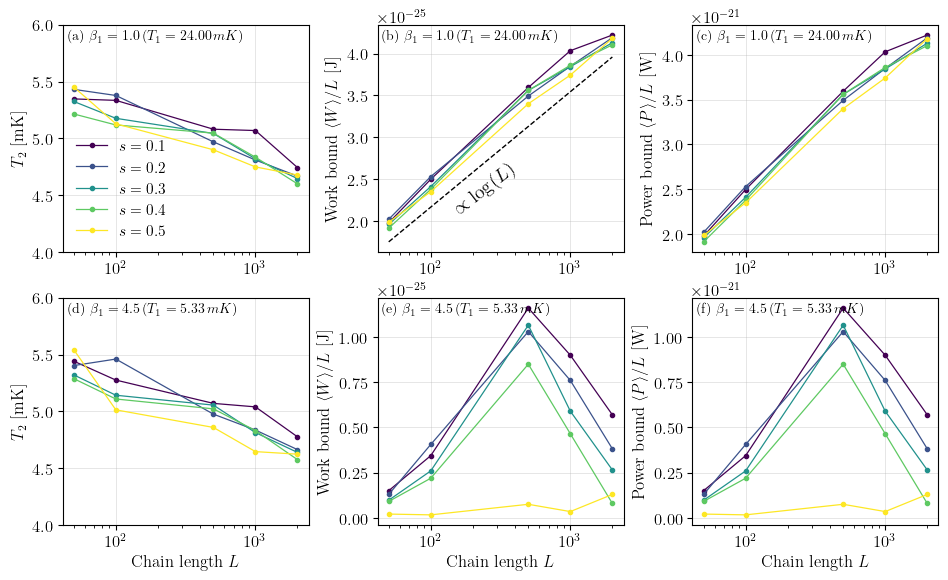

In [19]:
# Physical-unit scaling plots vs chain length
latex_plot(scale=1.8, fontsize=12)

scaling_path = f"{ROOT}/../data/results/scaling_1d_pegasus_unif_small_h"
scaling_chain_lengths = [50, 100, 300, 500, 1000, 2000]
scaling_beta1_targets = [1.0, 4.5]
scaling_s_values = [0.1, 0.2, 0.3, 0.4, 0.5]
scaling_selected_time_us = 100.0

scaling_records = []
for L in scaling_chain_lengths:
    scaling_path_L = f"{ROOT}/../data/results/phase_diagrams_1d_pegasus_unif_small_h" if L == 300 else scaling_path
    beta_raw = _as_dict(np.load(f"{scaling_path_L}/betas2_{L}.pkl", allow_pickle=True))
    q_raw = _as_dict(np.load(f"{scaling_path_L}/Q_{L}.pkl", allow_pickle=True))
    e_raw = _as_dict(np.load(f"{scaling_path_L}/energies_{L}.pkl", allow_pickle=True))

    for key, beta_est in beta_raw.items():
        if key not in q_raw or key not in e_raw:
            continue

        L_key, at_key, s_key, b1_key = key
        if int(float(L_key)) != L:
            continue
        if not np.isclose(float(at_key), scaling_selected_time_us):
            continue

        beta1_val = float(b1_key)
        s_val = float(s_key)
        if not any(np.isclose(beta1_val, target) for target in scaling_beta1_targets):
            continue
        if not any(np.isclose(s_val, target) for target in scaling_s_values):
            continue
        beta2_val = -float(beta_est)
        if np.isnan(beta2_val) or abs(beta2_val) <= 1e-10:
            continue

        Qmean, Qvar = q_raw[key]
        if abs(Qmean) <= 1e-10 and abs(Qvar) <= 1e-10:
            continue

        x = Qmean / np.sqrt(Qvar + Qmean**2)
        gx = x * np.arctanh(x)
        work_dimensionless = 2 / beta2_val * gx + (1 - (beta1_val / beta2_val)) * Qmean
        work_per_spin = work_dimensionless * energy_units

        scaling_records.append(
            {
                "L": L,
                "beta1": beta1_val,
                "s": s_val,
                "T2_mK": 1000.0 / (beta2_val * beta_units),
                "work_J_per_spin": work_per_spin,
                "power_W_per_spin": work_per_spin / (scaling_selected_time_us * 1e-6),
            }
        )

scaling_metrics = [
    ("T2_mK", r"$T_2$ [mK]"),
    ("work_J_per_spin", r"Work bound $\langle W \rangle / L $ [J]"),
    ("power_W_per_spin", r"Power bound $\langle P \rangle / L$ [W]"),
]

from matplotlib import gridspec
fig = plt.figure(figsize=(11.3, 6.5))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.2, wspace=0.28)
axs = np.array([fig.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]).reshape(2, 3)
for col_idx in range(3):
    axs[1, col_idx].sharex(axs[0, col_idx])
scaling_cmap = plt.get_cmap("viridis", len(scaling_s_values))
scaling_s_colors = {s: scaling_cmap(i) for i, s in enumerate(scaling_s_values)}

for row_idx, beta1 in enumerate(scaling_beta1_targets):
    for col_idx, (metric, ylabel) in enumerate(scaling_metrics):
        ax = axs[row_idx, col_idx]
        plotted_values = []

        for s in scaling_s_values:
            points = sorted(
                (
                    (row["L"], row[metric])
                    for row in scaling_records
                    if np.isclose(row["beta1"], beta1) and np.isclose(row["s"], s)
                ),
                key=lambda item: item[0],
            )
            if not points:
                continue

            L_vals = np.array([p[0] for p in points])
            y_vals = np.array([p[1] for p in points], dtype=float)
            valid = np.isfinite(y_vals)
            if not np.any(valid):
                continue

            plotted_values.extend(y_vals[valid])
            ax.plot(
                L_vals[valid],
                y_vals[valid],
                color=scaling_s_colors[s],
                marker="o",
                markersize=3,
                linewidth=0.9,
                label=fr"$s={s:.1f}$",
            )

        ax.set_xscale("log")
        # if metric == "T2_mK":
            # ax.set_yscale("log")
        # elif metric == "work_J_per_spin":
        #     ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
        # elif plotted_values and np.all(np.asarray(plotted_values) > 0):
        #     ax.set_yscale("log")
        if ax == axs[0, 0]:
            ax.legend(loc="best", frameon=False, fontsize=11)
            ax.set_ylim(4,6)
        if ax == axs[1, 0]:
            ax.set_ylim(4,6)

        if ax == axs[0, 1]:
            ax.plot(L_vals, 1e-24 * (0.06*np.log(L_vals) - 0.06), color="black", linestyle="--", linewidth=1.0)
            ax.text(0.3, 0.15, r"$\propto \log(L)$", color="black", fontsize=14, ha="left", va="bottom", transform=ax.transAxes, rotation=38)
            
        ax.set_ylabel(ylabel)
        panel_idx = row_idx * len(scaling_metrics) + col_idx
        panel_label = chr(ord("a") + panel_idx)
        T1_mK = 1000.0 / (beta1 * beta_units)
        ax.text(0.02, 0.98, fr"({panel_label}) $\beta_1={beta1:.1f}\, (T_1 = {T1_mK:.2f}\, mK)$", transform=ax.transAxes, ha="left", va="top", fontsize=10)
        ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.45)
        if row_idx == len(scaling_beta1_targets) - 1:
            ax.set_xlabel(r"Chain length $L$")

# handles, labels = axs[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
# fig.suptitle(fr"Physical per-spin scaling at $t={scaling_selected_time_us:g}\,\mu s$", y=1.08)
plt.savefig(f"1d_chain/scaling_bounds_vs_L_at_{scaling_selected_time_us}_1d_{hname}.pdf", bbox_inches='tight')
plt.show()
